<a href="https://colab.research.google.com/github/supsi-dacd-isaac/TeachDecisionMakingUncertainty/blob/main/group_work/stochastic_network_design/2026_DMUU_GroupWork1_solved_GridDesign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **❓ Problem Statement:**
You, acting as the DSO, must plan an investment in 3 new cables and 3 generation units to supply 4 nodes / households.


### **🧩 Network Components  (see the figure)**
A schematic diagram illustrates the network layout. The network has 4 nodes, $i=1,2,3,4$. These are components:

- **Energy Demand $(u)$:** Each node has a non-negative energy demand, represented by the vector $$u = [u_1,u_2,u_3,u_4]^\top$$
where $u_i$ represents the energy demanded by the household on node $i$.

- **Generators ($x$):** Generation can only be installed at Nodes 2, 3, and 4. The installed generation capacities are represented by the non-negative vector $$x = [x_2,x_3,x_4]^\top,$$ where $x_i$ defines the maximum power tht can be produced at node $i$.

- **Distribution Lines ($y$):** The allowed network topology is radial, with all demand nodes connected through Node 1. The power capacities of the three distribution feeders are represented by the non-negative vector $$y = [y_1,y_2,y_3]^\top,$$ where, for instance, $y_1$ is the maximum admissible power flow between nodes 1 and 2.

###**🎯 Design Variables and Objective function:**


**Your objective is to define a reliable design for the new grid such that:**

*   the investment cost is minimized —  proportional to the capacity installed;
*   the system constraints are satisfied - also consdiering uncertain energy demand.



Let the decision variables (**the design**) be defined as:
$$
a=\begin{bmatrix}x\\y\end{bmatrix}
=
\begin{bmatrix}
x_2 & x_3 & x_4 & y_1 & y_2 & y_3
\end{bmatrix}^\top,
$$

The objective is to find the optimal $a$ such that the total investment cost is minimized. The total cost is a linear function as follows::

$$ C^\top a = \begin{bmatrix}C_{x2} & C_{x3} & C_{x4}\end{bmatrix}  \begin{bmatrix}
x_2 \\ x_3 \\ x_4 \end{bmatrix} + \begin{bmatrix} C_{y1}& C_{y2}& C_{y3}\end{bmatrix}   \begin{bmatrix}
y_1 \\ y_2 \\ y_3 \end{bmatrix},$$

where $C = [C_x, C_y] $ define the costs per unit of capacity installed [CHF/pu] on the 3 generation nodes $C_x$ and lines $C_y$.

### **🛠️ Constraints:**

A few requirements (constraints) must be sattisfied  

The total generation capacity must exceed the demand

* $ \sum_{i=2}^{4} x_i \geq \sum_{i=1}^{4} u_i$

Node 1 does not have space for a generator. Hence, we need enough in-flow capacity to sattisfy the demand:
* $y_1 + y_2 + y_3 \geq u_1 $

Each demand node must be able to meet its demand through local generation and incoming flow:
* $x_2 + y_1 \geq u_2,$
* $x_3 + y_2 \geq u_3,$
* $x_4 + y_3 \geq u_4,$


If a node has excess generation, the corresponding line must be able to carry the surplus to other nodes or to the external grid:

* $y_1 \geq  x_2- u_2, $
* $y_2 \geq  x_3 - u_3, $
* $y_3 \geq  x_4 - u_4, $

> **Note**: There are 8 inequality constraints:
- total generation capacity,
- inflow capacity at Node 1,
- demand satisfaction at Node 2,
- demand satisfaction at Node 3,
- demand satisfaction at Node 4,
- line capacity at Node 2,
- line capacity at Node 3,
- line capacity at Node 4.




### **Compact LP Formulation**

Let the decision vector be $ a \in \mathcal A$, where $\mathcal A$ is the set of feasible actions defined by the lower and upper bounds on the capacities. The deterministic design optimization problem can be written compactly as a linear program:


\begin{align*}
\min_{a\in \mathcal{A}} \quad & c^T a
\\ \text{s.t.} \quad & A_{in}a \leq b_{in}(u) \end{align*}
where:

- $c^\top=\begin{bmatrix}C_x \\ C_y\end{bmatrix}^\top$ is the vector of unit investment costs,
- $A_{in}$ is the inequality constraint matrix,
- $b_{in}(u)$ is the right-hand-side vector




> **REMARK we need an equivalent form for standard LP solvers** Many solvers, including `scipy.optimize.linprog`, use constraints of the form $
A x \le b. $  


---

More explicitly

$$
-A_{in} a=
\begin{bmatrix}
1 & 1 & 1 & 0 & 0 & 0 \\
0 & 0 & 0 & 1 & 1 & 1 \\
1 & 0 & 0 & 1 & 0 & 0 \\
0 & 1 & 0 & 0 & 1 & 0 \\
0 & 0 & 1 & 0 & 0 & 1 \\
-1 & 0 & 0 & 1 & 0 & 0 \\
0 & -1 & 0 & 0 & 1 & 0 \\
0 & 0 & -1 & 0 & 0 & 1
\end{bmatrix} \begin{bmatrix}
x_2 \\ x_3 \\ x_4 \\ y_1 \\ y_2 \\ y_3
\end{bmatrix}
\quad \geq
-b_{in}(u) =
\begin{bmatrix}
u_1+u_2+u_3+u_4 \\
u_1 \\
u_2 \\
u_3 \\
u_4 \\
-u_2 \\
-u_3 \\
-u_4
\end{bmatrix}.$$



* Note that $b_{in}(u)$ depends on the demand vector $u$ and can be obtained from the vector $u$ as follows $Bu$. That is, matrix multiplication with a matrix of coefficients.

$$ B=
\begin{bmatrix}
1 & 1 & 1 & 1 \\
1 & 0 & 0 & 0 \\
0 & 1 & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1 \\
0 & -1 & 0 & 0 \\
0 & 0 & -1 & 0 \\
0 & 0 & 0 & -1
\end{bmatrix}
$$


###  **TASKS**

You will have to solve 4 main tasks (more details after):

1.   Solve the deterministic optimization
2.   Characterize and model the uncertainty
3.   Solve the optimization problem under uncertainty
4.   Validate and test the results, study error in the solution


* **[Task 1]** **✅Deterministic Optimal Solution of the capacity allocation problem**
Given the following data and information about the uncertainty of the system:

###*`NOMINAL DATA`* for the groups

| Group | $C_x$ | $C_y$ | nominal demand $u^{\text{nom}}$ | $x$ bounds | $y$ bounds |
|---|---|---|---|---|---|
| 1 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[0, 100]$ | $[0, 100]$ |
| 2 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[5, 100]$ | $[0, 100]$ |
| 3 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[5, 100]$ | $[0, 100]$ |
| 4 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[5, 100]$ | $[5, 100]$ |
| 5 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[0, 100]$ | $[0, 100]$ |
| 6 | $[5, 3, 4]$ | $[5, 4, 5]$ | $[22, 10, 25, 10]$ | $[0, 100]$ | $[5, 100]$ |

---
 - **Task 1.1 - Solve the deterministic optimization problem** Use the *`NOMINAL DATA`* of your group. (a code cell)
 - **Task 1.2 - Discuss the results** : What is the optimized capacity investment $a^{\star}_{det}$ and what is the resulting cost? Are there any unbalances ("over-built" or "under-built") parts of the network? Take a guess at why this is happening. (a text cell)




* **[Task 2]**  **🔄 Uncertainty Characterization and Modeling. Define decision-making program under uncertaity:**

  Recognize that the four loads $u$ are uncertain, hence might deviate from their nominal data. Some filed expert provided **`Additional Informaion on Uncertain Demand and Requirements`**. You will use this for **uncertainty characterization** and **uncertainty modelling**.
  
  
   - **Task 2.1 - Characterize the uncertainty** and discuss why you selected aleatoric or epistemic. Which modeling techniques are you going to use? Briefly justify your choice with a discussion. (a text cell)

   - **Task 2.2 - Qunatify the uncertainy** Write down the mathematical model you will use, explicitly. That is, an equation for the model you choose. How is this choice going to affect the decision-making problem? Discuss briefly. (a text cell)
   
   - **Task 2.3 - Define the decision-making problem**
        - Define the mathematical optimization under uncertainty. An equation for the optimization program that includes the model you defined in Task 2.2 (a text cell).
        - Then define the decision-making problem numerically ready for numerical solution in the next task. (a code cell)

### `Informaion on Uncertain Demand and Requirements`

 For Task 2, the nominal demand values from Task 1 are no longer assumed to be exact.  Each group receives additional information about how the demand may vary, but the type and amount of information differ from group to group.

---
- **Group 1**  
  Demand is uncertain, however, we do not know much yet about it. We cannot model its variability preciselly and only limited information is available. Expert judgment suggests that the true demand at each node will chance from the nominal value by an error no more than **±30%**. Worst-case scenarios are budgetted. That is, a situation where the simultaneous **±30% deviation at all nodes** occurs is unrealistic or highly unlikely. We do not have distributional information nor a PDF family. We wish to make sure the capacity constraints are always sattisfied, i.e., for all the uncertain demand scenarios considered without exceptions. Show to the experts how lower or higher budget on the worst-cases affect the solution.

---
- **Group 2**  
  Demand is uncertain, and enough quantitative information is available. For each node we know preciselly what is the **mean value of the demand** and its **standard deviation**. The mean value is equal to the nominal demand vector is $u^{\text{nom}}$ and the standard deviation at each node is assumed to be **15% of the corresponding nominal value**. We can safelly assume the shape of the probability density at each node is Gaussian and the demand at the individual nodes are uncorrelated. As an optional extension [for bouns points], you may also investigate with your model a positive correlation between the demand at the nodes could matter. The design should be chosen so that the network operates feasibly with probability at least **95%** (given the uncertianty model you selected).

---
- **Group 3**  
  Demand is uncertain, but the available information is currently very limited. Three expert suggests that the estimation error be **±10%**, **±20%** or **±30%** around the nominal demand. No further statistical information or worst-case information is provided. Your design should remain feasible under the uncertainty information provided. Show to the three experts how their estimate affect the solution.
   
---
- **Group 4**  
  Demand is uncertain, and historical data provide estimates of the **expected demand** and **standard deviation** at each node. The mean value is equal to the nominal demand vector is $u^{\text{nom}}$, and the standard deviation at each node is **10% of the corresponding nominal value**. We can safelly assume the shape of the probability density at each node is Gaussian and the demand at the individual nodes are uncorrelated. As an optional extension [for bouns points], you may also investigate with your model a positive correlation between the demand at the nodes could matter. The design should satisfy the network constraints with probability at least **97%** (given the uncertianty model you selected).

---
- **Group 5**  
  Demand is uncertain. The filed operator instead of a compact text description of the uncertainty provided **100 demand mesurements**. These samples can be interpreted as realizations of the true uncertain demand. Hence, you can choose how to use these **100 samples from the true load distribution**. You may use them to build an uncertainty model. Otherwise, you could optimize directly your design unsing a data-driven approach. The network design must satisfy the capacity constraints for all sampled scenarios. We can allow some of the scenarios to violate the constraints if explained and justified


  ```python
  import pandas as pd

  url_for_design = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task2_and_3.csv"

  # Load the CSV into a DataFrame
  data = pd.read_csv(url_for_design)

  # Display the first few rows
  data.head()
  ```


---
- **Group 6**  
  Demand is uncertain, and you are given a dataset containing **sampled demand realizations** for Tasks 2 and 3. As in Group 5, these samples represent possible realizations of the true uncertain demand and can be used directly to support the design process.


  ```python
  import pandas as pd

  url_for_design = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task2_and_3.csv"

  # Load the CSV into a DataFrame
  data = pd.read_csv(url_for_design)

  # Display the first few rows
  data.head()
  ```
---



* **[Task 3]** **🧠 Solve Decision-Making Problem Under Uncertainty**
  
   - **Task 3.1 - Optimize under uncertainty** Use the model define in the previous taks and find the optimized capacity investment $a^{\star}_{unc}$ under uncertainty. Compute the associated cost. (a code cell)
   
   - **Task 3.2 Discuss the results and compare** the results with the deterministic solution. Whcih one is more expensive? Are the results different? If yes why? if not why? How are the capacity installed? (a text cell)
  


  
---


* **[Task 4]** **🔎 Out-of-Sample Validation**.

  A validation data set  $\mathcal{D}=\{ u^{(i)} \}_{i=1}^{N},$ will be provided to verify how well the optimized solutions are performing. Essentially, we are interested in evaluating their performace based on a few representative indicatos. We will considere these:
  
  ***THE PERFORMANCE FUNCTIONS*** defined by the 8 constraints as: $$g(a, u)= A_{in}a - b_{in}(u) \in \mathbb{R}^8$$

  ***THE WORST CASE PERFORMANCE SCORE***:
   $$w (a^\star, \xi) = \max_{k\in{1,..,8}} g_k(a^\star, u) ~\forall~~ u\in \mathcal{D}.  $$
   The worst-case score tells us which one of the constriaint is closest to failure (largest negative value) and the severity of failure (largest positive value). If $w>0$, at least one of rows of the system of linear inequalities is not sattisfied, i.e., $g_k \leq 0$.  

   ***FAILURE PROBABILITY*** Joint and individual requirements

   $$P_{f,k}(a) = \mathbb{P}[ g_k(a, u)  > 0 ],k=1,...,8,$$  
   $$P_{F}(a) = \mathbb{P}[ w (a, u)  > 0],$$

   ***RISK*** an indicator of the expected total load at risk during failure
   $$Risk(a) = \mathbb{E}[u_{\text{total}} | w(a, u)>0],$$ where $u_{\text{total}} = \sum_{i=1}^4 u_i$ is the total demand at risk when the constraints are not sattisfied.
---
  
   - **Task 4.1 - Visualize the empirical PDF and CDF of the indicators** By using $\mathcal{D}$. Compare $a^\star_{det}$ and $a^\star_{unc}$. Visualize the probability density functions (PDFs) and cumulative distribution functions (CDFs) of the worst-case violation score $w$ together with the violation scores $g_k$ on the individual capcity requirements (code and text cells).
  
  - **Task 4.2 - Estimate these probabilities and discuss the results** EStimate $P_{f,k}(a),k=1,...,8,$ and $P_{F}(a)$ for the deterministic design, from task 1, and the design under uncertainty, from task 3. Discuss your findings and present a convergence plot to check for stability of the estimator. What is the most critical part of the network? Which constraints are most likely to fail?  How often does each design (deterministic and uncertain) violate constraints? (code and text cells).
  
  - **Task 4.3 - Estimate the demand at risk when we fail** Estimate the risk $Risk(a)$ for both designs.  Present a convergence plot to check if the estimator is stable.  (code and text cells)

---

#### **Validation data**
For all groups we have **N validation samples** for validation. A csv data frame `df_T4_validation` can be loaded as presented next example:



```python
import pandas as pd
url_data_validation = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task4_validation.csv"

# Load the CSV into a DataFrame
df_T4_validation = pd.read_csv(url_data_validation)

# Display the first few rows
df_T4_validation.head() # each row represent one load sample from the nodes
array_of_demand_data_in_node_1 = df_T4_validation.iloc[:,1].values
```
---





In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linprog
from scipy.stats import norm

url_for_design = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task2_and_3.csv"
url_data_validation = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/demand_data_task4_validation.csv"

url_for_design_g6 = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/data/generated_loadsG6_tasks_2_3.csv"
url_data_validation_g6 = "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/refs/heads/main/group_work/stochastic_network_design/data/generated_loadsG6_validation.csv"



d23 = pd.read_csv(url_for_design)
dval = pd.read_csv(url_data_validation)
d23_g6 = pd.read_csv(url_for_design_g6).drop(columns=["Unnamed: 0"])
dval_g6 = pd.read_csv(url_data_validation_g6).drop(columns=["Unnamed: 0"])


outdir = "network_design_all_groups_outputs"
os.makedirs(outdir, exist_ok=True)

u_nom = np.array([22.,10.,25.,10.])
cx = np.array([5.,3.,4.]); cy = np.array([5.,4.,5.]); c=np.r_[cx,cy]
groups = {1:{'x_lb':0,'y_lb':0},
          2:{'x_lb':5,'y_lb':0},
          3:{'x_lb':5,'y_lb':0},
          4:{'x_lb':5,'y_lb':5},
          5:{'x_lb':0,'y_lb':0},
          6:{'x_lb':0,'y_lb':5}}

A_ub = np.array([
    [-1,-1,-1, 0, 0, 0],
    [ 0, 0, 0,-1,-1,-1],
    [-1, 0, 0,-1, 0, 0],
    [ 0,-1, 0, 0,-1, 0],
    [ 0, 0,-1, 0, 0,-1],
    [ 1, 0, 0,-1, 0, 0],
    [ 0, 1, 0, 0,-1, 0],
    [ 0, 0, 1, 0, 0,-1],
], float)
M = np.array([
    [-1,-1,-1,-1],
    [-1, 0, 0, 0],
    [ 0,-1, 0, 0],
    [ 0, 0,-1, 0],
    [ 0, 0, 0,-1],
    [ 0, 1, 0, 0],
    [ 0, 0, 1, 0],
    [ 0, 0, 0, 1],
], float)

def b_of_u(u):
    u=np.array(u, float)
    return np.array([-u.sum(), -u[0], -u[1], -u[2], -u[3], u[1], u[2], u[3]], float)

def solve_det(group):
    bounds=[(groups[group]['x_lb'],100)]*3 + [(groups[group]['y_lb'],100)]*3
    return linprog(c, A_ub=A_ub, b_ub=b_of_u(u_nom), bounds=bounds, method='highs')

def budgeted_rowwise_min_b(u_nom, rho, Gamma):
    res=[]
    for m in M:
        weights=np.abs(m)*u_nom
        order=np.argsort(weights)[::-1]
        rem=Gamma
        worst_extra=0.0
        for idx in order:
            if rem<=1e-12:
                break
            take=min(1.0, rem)
            worst_extra += weights[idx]*take
            rem -= take
        res.append(m@u_nom - rho*worst_extra)
    return np.array(res)

def solve_budgeted(group, rho, Gamma):
    b_rob = budgeted_rowwise_min_b(u_nom, rho, Gamma)
    bounds=[(groups[group]['x_lb'],100)]*3 + [(groups[group]['y_lb'],100)]*3
    return linprog(c, A_ub=A_ub, b_ub=b_rob, bounds=bounds, method='highs')

def solve_chance(group, sigma_frac, joint_prob, corr=None):
    alpha = 1-joint_prob
    alpha_alloc = np.full(8, alpha/8.0)
    sigma_u = sigma_frac*u_nom
    if corr is None:
        Sigma = np.diag(sigma_u**2)
    else:
        R = np.full((4,4), corr); np.fill_diagonal(R,1.0)
        Sigma = np.outer(sigma_u, sigma_u)*R
    mu_b = b_of_u(u_nom)
    sigma_b = np.sqrt(np.einsum('ij,jk,ik->i', M, Sigma, M))
    b_cc = mu_b + norm.ppf(alpha_alloc)*sigma_b
    bounds=[(groups[group]['x_lb'],100)]*3 + [(groups[group]['y_lb'],100)]*3
    return linprog(c, A_ub=A_ub, b_ub=b_cc, bounds=bounds, method='highs')

def solve_scenario_all(group, samples):
    A_big = np.repeat(A_ub[None,:,:], len(samples), axis=0).reshape(-1,6)
    b_big = np.concatenate([b_of_u(u) for u in samples])
    bounds=[(groups[group]['x_lb'],100)]*3 + [(groups[group]['y_lb'],100)]*3
    return linprog(c, A_ub=A_big, b_ub=b_big, bounds=bounds, method='highs')

def solve_scenario_slack(group, samples):
    A_big = np.repeat(A_ub[None,:,:], len(samples), axis=0).reshape(-1,6)
    b_big = np.concatenate([b_of_u(u) for u in samples])
    bounds=[(groups[group]['x_lb'],100)]*3 + [(groups[group]['y_lb'],100)]*3
    return linprog(c, A_ub=A_big, b_ub=b_big, bounds=bounds, method='highs')


def g_matrix(a, U):
    return (A_ub @ np.array(a))[None,:] - np.atleast_2d(U) @ M.T

def validation_metrics(a, U):
    G = g_matrix(a,U)
    w = G.max(axis=1)
    pfk = (G>0).mean(axis=0)
    pfj = (w>0).mean()
    total = U.sum(axis=1)
    risk = total[w>0].mean() if np.any(w>0) else 0.0
    return G, w, pfk, pfj, risk

samples_g5 = d23.values
samples_g6 = d23_g6.values
Uval = dval.values

# Example: print all key solutions
print("Deterministic solutions")
for g in range(1,7):
    r=solve_det(g)
    print(g, r.x, r.fun)

print("\nGroup 1 budgeted robust")
for G in [1,2,3,4]:
    r=solve_budgeted(1,0.3,G)
    print("Gamma=",G, "x=",r.x, "cost=",r.fun)

print("\nGroup 2 chance-constrained")
r=solve_chance(2,0.15,0.95)
print(r.x, r.fun)

print("\nGroup 3 robust-box")
for rho in [0.1,0.2,0.3]:
    r=solve_budgeted(3,rho,4)
    print("rho=",rho, "x=",r.x, "cost=",r.fun)

print("\nGroup 4 chance-constrained")
r=solve_chance(4,0.10,0.97)
print(r.x, r.fun)

print("\nGroup 5 scenario-robust")
r=solve_scenario_all(5, samples_g5)
print(r.x, r.fun)

print("\nGroup 6 scenario-robust")
r=solve_scenario_all(6, samples_g6)
print(r.x, r.fun)


Deterministic solutions
1 [10. 47. 10. -0. 22.  0.] 319.0
2 [10. 47. 10. -0. 22.  0.] 319.0
3 [10. 47. 10. -0. 22.  0.] 319.0
4 [15. 37. 15.  5. 12.  5.] 344.0
5 [10. 47. 10. -0. 22.  0.] 319.0
6 [15. 37. 15.  5. 12.  5.] 344.0

Group 1 budgeted robust
Gamma= 1 x= [10.  54.5 10.   3.  37.   3. ] cost= 431.5
Gamma= 2 x= [10.  61.1 10.   3.  43.6  3. ] cost= 477.69999999999993
Gamma= 3 x= [10.  64.1 10.   3.  46.6  3. ] cost= 498.69999999999993
Gamma= 4 x= [10.  67.1 10.   3.  49.6  3. ] cost= 519.6999999999999

Group 2 chance-constrained
[10.         60.55508696 10.          3.74655821 44.92148249  3.74655821] 488.8167729511876

Group 3 robust-box
rho= 0.1 x= [10.  53.7 10.   1.  31.2  1. ] cost= 385.90000000000003
rho= 0.2 x= [10.  60.4 10.   2.  40.4  2. ] cost= 452.80000000000007
rho= 0.3 x= [10.  67.1 10.   3.  49.6  3. ] cost= 519.6999999999999

Group 4 chance-constrained
[12.32621268 52.02136522 12.32621268  5.         33.70583351  5.        ] 451.8233438637478

Group 5 scenario-r

In [ ]:
import numpy as np
from scipy.optimize import linprog
from scipy import sparse

def solve_scenario_slack(group, samples, slack_penalty=1000.0):
    """
    Solve the scenario-based design problem with one nonnegative slack
    variable per (scenario, constraint).

    Decision vector:
        z = [a, s]
    where
        a = [x2, x3, x4, y1, y2, y3]
        s >= 0 are violation slacks

    Objective:
        min c^T a + slack_penalty * sum(s)

    Constraints for each scenario j:
        A_ub a - s_j <= b_of_u(u_j)
    """
    samples = np.asarray(samples)
    n_scen = len(samples)
    n_con = A_ub.shape[0]   # should be 8
    n_a = 6
    n_slack = n_scen * n_con
    n_var = n_a + n_slack

    # Objective: original costs on a, penalty on slacks
    c_full = np.concatenate([
        c,
        slack_penalty * np.ones(n_slack)
    ])

    # Build block constraints:
    # [A_big  -I] [a] <= b_big
    #            [s]
    A_big = np.repeat(A_ub[None, :, :], n_scen, axis=0).reshape(-1, n_a)
    b_big = np.concatenate([b_of_u(u) for u in samples])

    A_left = sparse.csr_matrix(A_big)
    A_right = -sparse.eye(n_slack, format="csr")
    A_full = sparse.hstack([A_left, A_right], format="csr")

    # Bounds
    a_bounds = [(groups[group]['x_lb'], 100)] * 3 + [(groups[group]['y_lb'], 100)] * 3
    slack_bounds = [(0, None)] * n_slack
    bounds = a_bounds + slack_bounds

    res = linprog(
        c_full,
        A_ub=A_full,
        b_ub=b_big,
        bounds=bounds,
        method='highs'
    )

    if res.success:
        a_opt = res.x[:n_a]
        s_opt = res.x[n_a:].reshape(n_scen, n_con)
        return {
            "result": res,
            "a_opt": a_opt,
            "slacks": s_opt,
            "total_slack": s_opt.sum(),
            "max_slack": s_opt.max(),
            "violated_entries": np.sum(s_opt > 1e-9)
        }
    else:
        return {
            "result": res,
            "a_opt": None,
            "slacks": None
        }

In [ ]:
sol = solve_scenario_slack(group=6, samples=samples_g6, slack_penalty=0.1)

print(sol["a_opt"])
print("Total slack:", sol["total_slack"])
print("Max slack:", sol["max_slack"])
print("Violated entries:", sol["violated_entries"])

[ 9.0491827  54.63832696  9.39504495  6.38118316 47.77135592  6.68483222]
Total slack: 859.6493479921013
Max slack: 39.3852187791774
Violated entries: 204


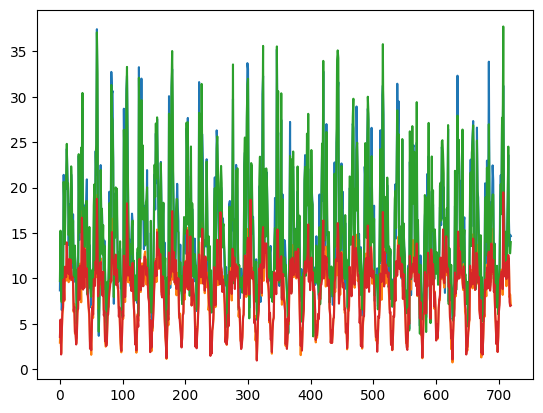

In [ ]:
import matplotlib.pyplot as plt

plt.plot(d23_g6)

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog

train =  d23_g6
val =  dval_g6


u_nom = np.array([22,10,25,10], dtype=float)
c = np.array([5,3,4,5,4,5], dtype=float)
bounds = [(0,100)]*3 + [(5,100)]*3  # Group 6

# deterministic benchmark
res_det = linprog(c, A_ub=A_ub, b_ub=b_of_u(u_nom), bounds=bounds)

# scenario-robust uncertain design: satisfy all training samples
A_scen = np.vstack([A_ub for _ in range(len(train))])
b_scen = np.concatenate([b_of_u(row) for row in train.to_numpy()])
res_unc = linprog(c, A_ub=A_scen, b_ub=b_scen, bounds=bounds)

print("deterministic:", res_det.fun, res_det.x)
print("uncertain:", res_unc.fun, res_unc.x)

def g_vals(a, U):
    U = np.asarray(U, float)
    if U.ndim == 1:
        U = U[None, :]
    Aa = A_ub @ a
    return np.array([Aa - b_of_u(u) for u in U])

def validation_metrics(a, U):
    g = g_vals(a, U)
    w = g.max(axis=1)
    return {
        "pf_ind": (g > 0).mean(axis=0),
        "pf_joint": (w > 0).mean(),
        "risk": U[w > 0].sum(axis=1).mean() if np.any(w > 0) else 0.0,
    }

print("det val:", validation_metrics(res_det.x, val.to_numpy()))
print("unc val:", validation_metrics(res_unc.x, val.to_numpy()))


deterministic: 344.0 [15. 37. 15.  5. 12.  5.]
uncertain: 814.810082957926 [ 9.94639511 92.31245469 10.20892358  9.21985135 88.71388025  9.27005425]
det val: {'pf_ind': array([0.14555556, 0.15152778, 0.        , 0.        , 0.        ,
       0.60527778, 0.91416667, 0.60458333]), 'pf_joint': np.float64(0.9998611111111111), 'risk': np.float64(47.17143728919828)}
unc val: {'pf_ind': array([0.00083333, 0.        , 0.        , 0.        , 0.        ,
       0.00111111, 0.00138889, 0.00194444]), 'pf_joint': np.float64(0.004722222222222222), 'risk': np.float64(31.900450064326645)}


In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import linprog
from scipy.stats import norm
from scipy import sparse

# ============================================================
# URLs
# ============================================================
URL_TASK23_COMMON = (
    "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/"
    "refs/heads/main/group_work/stochastic_network_design/demand_data_task2_and_3.csv"
)
URL_TASK4_COMMON = (
    "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/"
    "refs/heads/main/group_work/stochastic_network_design/demand_data_task4_validation.csv"
)

use_new_data=False
if use_new_data:
  URL_G6_TASK23 = (
      "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/"
      "refs/heads/main/group_work/stochastic_network_design/data/generated_loadsG5_tasks_2_3.csv"
  )
  URL_G6_TASK4 = (
      "https://raw.githubusercontent.com/supsi-dacd-isaac/TeachDecisionMakingUncertainty/"
      "refs/heads/main/group_work/stochastic_network_design/data/generated_loadsG5_validation.csv"
  )
else:
  URL_G6_TASK23  = URL_TASK23_COMMON
  URL_G6_TASK4 = URL_TASK4_COMMON

# ============================================================
# Problem data
# ============================================================
U_NOM = np.array([22.0, 10.0, 25.0, 10.0])
C_X = np.array([5.0, 3.0, 4.0])
C_Y = np.array([5.0, 4.0, 5.0])
C = np.concatenate([C_X, C_Y])

GROUPS = {
    1: {"x_lb": 0.0, "y_lb": 0.0},
    2: {"x_lb": 5.0, "y_lb": 0.0},
    3: {"x_lb": 5.0, "y_lb": 0.0},
    4: {"x_lb": 5.0, "y_lb": 5.0},
    5: {"x_lb": 0.0, "y_lb": 0.0},
    6: {"x_lb": 0.0, "y_lb": 5.0},
}

# A_ub a <= b(u)  with violation score g(a,u) = A_ub a - b(u) <= 0
A_UB = np.array([
    [-1, -1, -1,  0,  0,  0],  # total generation >= total demand
    [ 0,  0,  0, -1, -1, -1],  # y1+y2+y3 >= u1
    [-1,  0,  0, -1,  0,  0],  # x2+y1 >= u2
    [ 0, -1,  0,  0, -1,  0],  # x3+y2 >= u3
    [ 0,  0, -1,  0,  0, -1],  # x4+y3 >= u4
    [ 1,  0,  0, -1,  0,  0],  # x2-y1 <= u2
    [ 0,  1,  0,  0, -1,  0],  # x3-y2 <= u3
    [ 0,  0,  1,  0,  0, -1],  # x4-y3 <= u4
], dtype=float)

CONSTRAINT_NAMES = [
    "total_generation",
    "node1_inflow",
    "node2_supply",
    "node3_supply",
    "node4_supply",
    "node2_export",
    "node3_export",
    "node4_export",
]


def b_of_u(u: np.ndarray) -> np.ndarray:
    u = np.asarray(u, dtype=float)
    return np.array([
        -u.sum(),
        -u[0],
        -u[1],
        -u[2],
        -u[3],
         u[1],
         u[2],
         u[3],
    ], dtype=float)


def load_samples(url: str) -> np.ndarray:
    df = pd.read_csv(url)
    # Keep first 4 numeric columns only (u1...u4)
    numeric = df.select_dtypes(include=[np.number]).iloc[:, :4]
    if numeric.shape[1] != 4:
        raise ValueError(f"Expected 4 numeric demand columns, got shape {numeric.shape} from {url}")
    return numeric.to_numpy(dtype=float)


def make_bounds(group: int):
    x_lb = GROUPS[group]["x_lb"]
    y_lb = GROUPS[group]["y_lb"]
    return [(x_lb, 100.0)] * 3 + [(y_lb, 100.0)] * 3


# ============================================================
# Solvers
# ============================================================

def solve_deterministic(group: int, u_nom: np.ndarray = U_NOM):
    res = linprog(C, A_ub=A_UB, b_ub=b_of_u(u_nom), bounds=make_bounds(group))
    if not res.success:
        raise RuntimeError(f"Deterministic solve failed for group {group}: {res.message}")
    return res


# ----- Robust helpers for Groups 1 and 3 -----

def max_weighted_deviation(weights: np.ndarray, budget: float, delta_frac: float) -> float:
    """
    max sum_i weights_i * delta_frac * u_nom_i * z_i
    s.t. 0 <= z_i <= 1, sum z_i <= budget.
    weights assumed nonnegative.
    """
    impacts = np.asarray(weights, dtype=float) * delta_frac * U_NOM
    order = np.argsort(-impacts)
    remaining = float(budget)
    out = 0.0
    for idx in order:
        if remaining <= 0:
            break
        take = min(1.0, remaining)
        out += impacts[idx] * take
        remaining -= take
    return out


def robust_rhs_group1(gamma: float, delta_frac: float = 0.30) -> np.ndarray:
    # Need min_u b_k(u) over the budgeted uncertainty set.
    b = np.zeros(8, dtype=float)

    # row 1: -sum(u) -> minimized when total demand is maximized with budget Gamma
    b[0] = -(U_NOM.sum() + max_weighted_deviation(np.ones(4), gamma, delta_frac))

    # rows 2-5: -u_i -> minimized by maximizing that node demand
    scale_up = 1.0 + delta_frac * min(1.0, gamma)
    b[1] = -(U_NOM[0] * scale_up)
    b[2] = -(U_NOM[1] * scale_up)
    b[3] = -(U_NOM[2] * scale_up)
    b[4] = -(U_NOM[3] * scale_up)

    # rows 6-8: +u_i -> minimized by minimizing that node demand
    scale_dn = 1.0 - delta_frac * min(1.0, gamma)
    b[5] = U_NOM[1] * scale_dn
    b[6] = U_NOM[2] * scale_dn
    b[7] = U_NOM[3] * scale_dn
    return b

def solve_group1_robust(group: int, gamma: float, delta_frac: float = 0.30):
    res = linprog(C, A_ub=A_UB, b_ub=robust_rhs_group1(gamma, delta_frac), bounds=make_bounds(group))
    if not res.success:
        raise RuntimeError(f"Group 1 robust solve failed (Gamma={gamma}): {res.message}")
    return res

def robust_rhs_box(delta_frac: float) -> np.ndarray:
    b = np.zeros(8, dtype=float)
    b[0] = -(U_NOM.sum() * (1.0 + delta_frac))
    b[1] = -(U_NOM[0] * (1.0 + delta_frac))
    b[2] = -(U_NOM[1] * (1.0 + delta_frac))
    b[3] = -(U_NOM[2] * (1.0 + delta_frac))
    b[4] = -(U_NOM[3] * (1.0 + delta_frac))
    b[5] = U_NOM[1] * (1.0 - delta_frac)
    b[6] = U_NOM[2] * (1.0 - delta_frac)
    b[7] = U_NOM[3] * (1.0 - delta_frac)
    return b


def solve_group3_box_robust(group: int, delta_frac: float):
    res = linprog(C, A_ub=A_UB, b_ub=robust_rhs_box(delta_frac), bounds=make_bounds(group))
    if not res.success:
        raise RuntimeError(f"Group 3 robust solve failed (rho={delta_frac}): {res.message}")
    return res


# ----- Chance constraints for Groups 2 and 4 -----

def chance_constraint_rhs(alpha_total: float, sigma_frac: float) -> np.ndarray:
    mu_u = U_NOM.copy()
    sigma_u = sigma_frac * U_NOM
    Sigma = np.diag(sigma_u ** 2)

    # b_k(u) = m_k^T u
    M = np.array([
        [-1, -1, -1, -1],
        [-1,  0,  0,  0],
        [ 0, -1,  0,  0],
        [ 0,  0, -1,  0],
        [ 0,  0,  0, -1],
        [ 0,  1,  0,  0],
        [ 0,  0,  1,  0],
        [ 0,  0,  0,  1],
    ], dtype=float)

    alpha_k = alpha_total / A_UB.shape[0]  # Bonferroni
    z = norm.ppf(alpha_k)  # lower quantile, negative

    mu_b = M @ mu_u
    sigma_b = np.sqrt(np.einsum("ij,jk,ik->i", M, Sigma, M))
    return mu_b + z * sigma_b



def solve_gaussian_chance(group: int, alpha_total: float, sigma_frac: float):
    b_cc = chance_constraint_rhs(alpha_total=alpha_total, sigma_frac=sigma_frac)
    res = linprog(C, A_ub=A_UB, b_ub=b_cc, bounds=make_bounds(group), method="highs")
    if not res.success:
        raise RuntimeError(f"Chance-constrained solve failed for group {group}: {res.message}")
    return res


# ----- Scenario robust / slack for Groups 5 and 6 -----

def solve_scenario_hard(group: int, samples: np.ndarray):
    n_scen = len(samples)
    A_big = np.repeat(A_UB[None, :, :], n_scen, axis=0).reshape(-1, 6)
    b_big = np.concatenate([b_of_u(u) for u in samples])
    res = linprog(C, A_ub=A_big, b_ub=b_big, bounds=make_bounds(group), method="highs")
    if not res.success:
        raise RuntimeError(f"Scenario hard solve failed for group {group}: {res.message}")
    return res



def solve_scenario_slack(group: int, samples: np.ndarray, slack_penalty: float = 1000.0):
    n_scen = len(samples)
    n_con = A_UB.shape[0]
    n_a = 6
    n_slack = n_scen * n_con

    c_full = np.concatenate([C, slack_penalty * np.ones(n_slack)])

    A_big = np.repeat(A_UB[None, :, :], n_scen, axis=0).reshape(-1, n_a)
    b_big = np.concatenate([b_of_u(u) for u in samples])

    A_left = sparse.csr_matrix(A_big)
    A_right = -sparse.eye(n_slack, format="csr")
    A_full = sparse.hstack([A_left, A_right], format="csr")

    bounds = make_bounds(group) + [(0.0, None)] * n_slack
    res = linprog(c_full, A_ub=A_full, b_ub=b_big, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(f"Scenario slack solve failed for group {group}: {res.message}")
    return res


# ============================================================
# KPI evaluation

def violation_matrix(a: np.ndarray, samples: np.ndarray) -> np.ndarray:
    a = np.asarray(a, dtype=float)
    G = np.vstack([A_UB @ a - b_of_u(u) for u in samples])
    return G



def compute_kpis(a: np.ndarray, cost: float, validation_samples: np.ndarray) -> dict:
    G = violation_matrix(a, validation_samples)
    w = G.max(axis=1)
    fail = w > 1e-12
    u_tot = validation_samples.sum(axis=1)

    out = {
        "cost": float(cost),
        "PF_joint": float(fail.mean()),
        "Risk": float(u_tot[fail].mean()) if fail.any() else 0.0,
        "mean_w": float(w.mean()),
        "p95_w": float(np.quantile(w, 0.95)),
        "max_w": float(w.max()),
        "mean_total_demand": float(u_tot.mean()),
        "n_validation": int(len(validation_samples)),
    }
    for k, name in enumerate(CONSTRAINT_NAMES):
        out[f"PF_{name}"] = float((G[:, k] > 1e-12).mean())
    return out


# ============================================================
# Build all designs and KPI tables

def build_all_tables(
    group1_gamma_values=(1, 2, 3, 4),
    group3_rho_values=(0.10, 0.20, 0.30),
    group5_use_slack=False,
    group6_use_slack=False,
    group5_slack_penalty=1000.0,
    group6_slack_penalty=1000.0,
    save_prefix="all_groups_kpis",
):
    # Load samples
    samples_common_task23 = load_samples(URL_TASK23_COMMON)
    samples_common_val = load_samples(URL_TASK4_COMMON)
    samples_g6_task23 = load_samples(URL_G6_TASK23)
    samples_g6_val = load_samples(URL_G6_TASK4)

    rows = []

    def append_row(group, variant, design_type, res, validation_samples, extra=None):
        a = res.x[:6].copy()
        row = {
            "group": group,
            "variant": variant,
            "design_type": design_type,
            "x2": a[0], "x3": a[1], "x4": a[2],
            "y1": a[3], "y2": a[4], "y3": a[5],
        }
        row.update(compute_kpis(a, res.fun, validation_samples))
        if extra:
            row.update(extra)
        rows.append(row)

    # Deterministic designs for all groups
    for g in range(1, 7):
        det = solve_deterministic(g)
        val = samples_g6_val if g == 6 else samples_common_val
        append_row(g, "det", "deterministic", det, val)

    # Group 1 robust for different budgets
    for gamma in group1_gamma_values:
        res = solve_group1_robust(1, gamma=gamma, delta_frac=0.30)
        append_row(1, f"unc_Gamma={gamma}", "uncertain", res, samples_common_val, extra={"Gamma": gamma})

    # Group 2 chance constraint
    res2 = solve_gaussian_chance(2, alpha_total=0.05, sigma_frac=0.15)
    append_row(2, "unc_95pct_gaussian", "uncertain", res2, samples_common_val, extra={"alpha_total": 0.05, "sigma_frac": 0.15})

    # Group 3 robust for different expert boxes
    for rho in group3_rho_values:
        res = solve_group3_box_robust(3, delta_frac=rho)
        append_row(3, f"unc_box={rho:.0%}", "uncertain", res, samples_common_val, extra={"rho": rho})

    # Group 4 chance constraint
    res4 = solve_gaussian_chance(4, alpha_total=0.03, sigma_frac=0.10)
    append_row(4, "unc_97pct_gaussian", "uncertain", res4, samples_common_val, extra={"alpha_total": 0.03, "sigma_frac": 0.10})

    # Group 5 sample-based
    if group5_use_slack:
        res5 = solve_scenario_slack(5, samples_common_task23, slack_penalty=group5_slack_penalty)
        extra5 = {"scenario_solver": "slack", "slack_penalty": group5_slack_penalty}
    else:
        res5 = solve_scenario_hard(5, samples_common_task23)
        extra5 = {"scenario_solver": "hard"}
    append_row(5, "unc_sample_based", "uncertain", res5, samples_common_val, extra=extra5)

    # Group 6 sample-based with dedicated samples
    if group6_use_slack:
        res6 = solve_scenario_slack(6, samples_g6_task23, slack_penalty=group6_slack_penalty)
        extra6 = {"scenario_solver": "slack", "slack_penalty": group6_slack_penalty}
    else:
        res6 = solve_scenario_hard(6, samples_g6_task23)
        extra6 = {"scenario_solver": "hard"}
    append_row(6, "unc_sample_based", "uncertain", res6, samples_g6_val, extra=extra6)

    df = pd.DataFrame(rows)

    # Compact summary table
    summary_cols = [
        "group", "variant", "design_type",
        "x2", "x3", "x4", "y1", "y2", "y3",
        "cost", "PF_joint", "Risk", "mean_w", "p95_w", "max_w"
    ]
    df_summary = df[summary_cols].copy()

    # Individual failure probability table
    pf_cols = ["group", "variant", "design_type"] + [f"PF_{name}" for name in CONSTRAINT_NAMES]
    df_pf = df[pf_cols].copy()

    # Save
    df.to_csv(f"{save_prefix}_full.csv", index=False)
    df_summary.to_csv(f"{save_prefix}_summary.csv", index=False)
    df_pf.to_csv(f"{save_prefix}_constraint_pf.csv", index=False)

    return df, df_summary, df_pf


if __name__ == "__main__":
    pd.set_option("display.width", 220)
    pd.set_option("display.max_columns", 100)

    df_full, df_summary, df_pf = build_all_tables(
        group1_gamma_values=(1, 2, 3, 4),
        group3_rho_values=(0.10, 0.20, 0.30),
        group5_use_slack=False,
        group6_use_slack=True,   # <- this is the key fix
        group6_slack_penalty=0.20,
    )

    print("\n=== SUMMARY TABLE ===")
    print(df_summary.round(4).to_string(index=False))

    print("\n=== INDIVIDUAL CONSTRAINT FAILURE PROBABILITIES ===")
    print(df_pf.round(4).to_string(index=False))

    print("\nSaved files:")
    print("  - all_groups_kpis_full.csv")
    print("  - all_groups_kpis_summary.csv")
    print("  - all_groups_kpis_constraint_pf.csv")



=== SUMMARY TABLE ===
 group            variant   design_type      x2      x3      x4      y1      y2     y3     cost  PF_joint    Risk  mean_w   p95_w   max_w
     1                det deterministic 10.0000 47.0000 10.0000 -0.0000 22.0000 0.0000 319.0000    1.0000 67.0471  2.7062  6.4252 16.0549
     2                det deterministic 10.0000 47.0000 10.0000 -0.0000 22.0000 0.0000 319.0000    1.0000 67.0471  2.7062  6.4252 16.0549
     3                det deterministic 10.0000 47.0000 10.0000 -0.0000 22.0000 0.0000 319.0000    1.0000 67.0471  2.7062  6.4252 16.0549
     4                det deterministic 15.0000 37.0000 15.0000  5.0000 12.0000 5.0000 344.0000    0.9902 67.0581  2.6411  6.4252 16.0549
     5                det deterministic 10.0000 47.0000 10.0000 -0.0000 22.0000 0.0000 319.0000    1.0000 67.0471  2.7062  6.4252 16.0549
     6                det deterministic 15.0000 37.0000 15.0000  5.0000 12.0000 5.0000 344.0000    0.9902 67.0581  2.6411  6.4252 16.0549
     1     